In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle

In [2]:
df = pd.read_csv('../datasets/Fertilizer Prediction.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (99, 9)

Columns: ['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64


In [4]:
print("Total duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Total duplicate rows: 0
After removing duplicates: (99, 9)


In [5]:
print(df.dtypes)

Temparature        int64
Humidity           int64
Moisture           int64
Soil Type            str
Crop Type            str
Nitrogen           int64
Potassium          int64
Phosphorous        int64
Fertilizer Name      str
dtype: object


In [6]:
df.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,30.282828,59.151515,43.181818,18.909091,3.383838,18.606061
std,3.502304,5.840331,11.271568,11.599693,5.814667,13.476978
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,54.000000,34.000000,10.000000,0.000000,9.000000
50%,30.000000,60.000000,41.000000,13.000000,0.000000,19.000000
75%,33.000000,64.000000,50.500000,24.000000,7.500000,30.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


In [7]:
# Strip extra spaces from column names
df.columns = df.columns.str.strip()
print("Cleaned column names:", df.columns.tolist())

Cleaned column names: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']


In [8]:
print("Unique Soil Types:")
print(df['Soil Type'].unique())

print("\nUnique Crop Types:")
print(df['Crop Type'].unique())

print("\nUnique Fertilizers:")
print(df['Fertilizer Name'].unique())

Unique Soil Types:
<StringArray>
['Sandy', 'Loamy', 'Black', 'Red', 'Clayey']
Length: 5, dtype: str

Unique Crop Types:
<StringArray>
[      'Maize',   'Sugarcane',      'Cotton',     'Tobacco',       'Paddy',
      'Barley',       'Wheat',     'Millets',   'Oil seeds',      'Pulses',
 'Ground Nuts']
Length: 11, dtype: str

Unique Fertilizers:
<StringArray>
['Urea', 'DAP', '14-35-14', '28-28', '17-17-17', '20-20', '10-26-26']
Length: 7, dtype: str


In [9]:
df['Soil Type'] = df['Soil Type'].str.strip().str.title()
df['Crop Type'] = df['Crop Type'].str.strip().str.title()
df['Fertilizer Name'] = df['Fertilizer Name'].str.strip().str.title()

print("After standardizing:")
print("\nSoil Types:", df['Soil Type'].unique())
print("\nCrop Types:", df['Crop Type'].unique())
print("\nFertilizers:", df['Fertilizer Name'].unique())

After standardizing:

Soil Types: <StringArray>
['Sandy', 'Loamy', 'Black', 'Red', 'Clayey']
Length: 5, dtype: str

Crop Types: <StringArray>
[      'Maize',   'Sugarcane',      'Cotton',     'Tobacco',       'Paddy',
      'Barley',       'Wheat',     'Millets',   'Oil Seeds',      'Pulses',
 'Ground Nuts']
Length: 11, dtype: str

Fertilizers: <StringArray>
['Urea', 'Dap', '14-35-14', '28-28', '17-17-17', '20-20', '10-26-26']
Length: 7, dtype: str


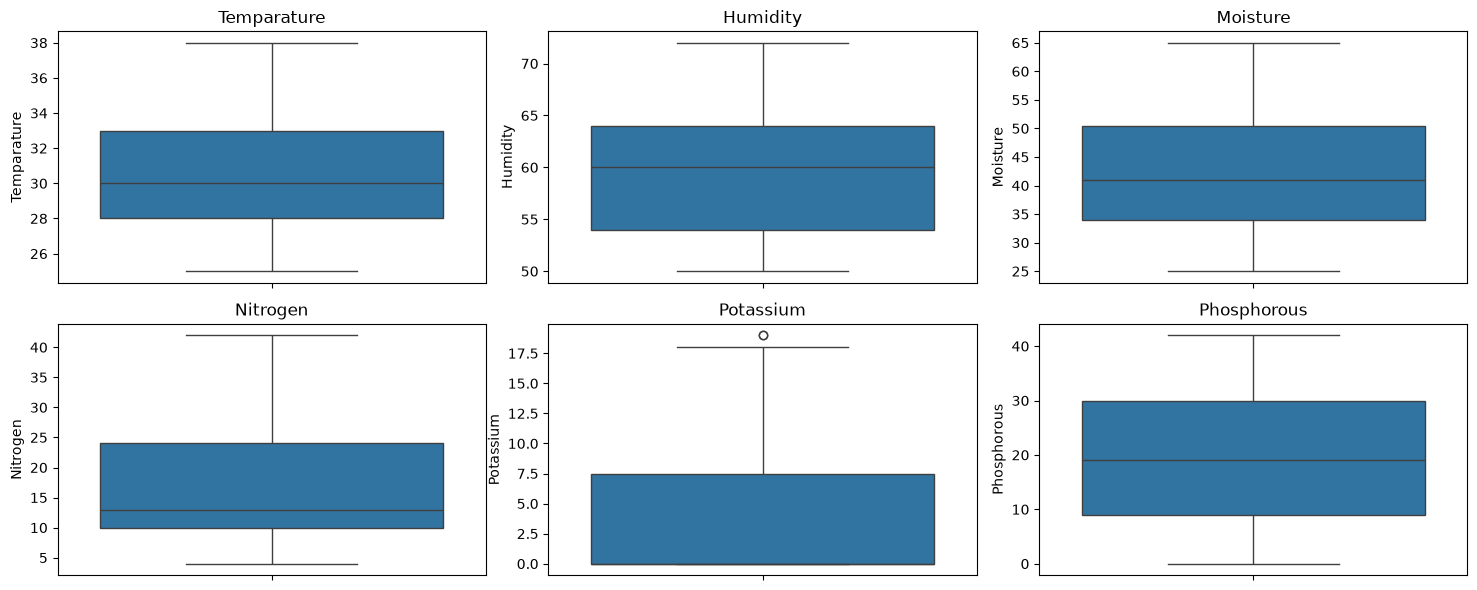

In [10]:
features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']

plt.figure(figsize=(15, 6))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
df = df[df['Temparature'].between(0, 60)]
df = df[df['Humidity'].between(0, 100)]
df = df[df['Moisture'].between(0, 100)]
df = df[df['Nitrogen'] >= 0]
df = df[df['Potassium'] >= 0]
df = df[df['Phosphorous'] >= 0]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (99, 9)


In [12]:
# Encode Soil Type
le_soil = LabelEncoder()
df['soil_encoded'] = le_soil.fit_transform(df['Soil Type'])

# Encode Crop Type
le_crop_fert = LabelEncoder()
df['crop_encoded'] = le_crop_fert.fit_transform(df['Crop Type'])

# Encode Fertilizer Name (this is our target/output)
le_fertilizer = LabelEncoder()
df['fertilizer_encoded'] = le_fertilizer.fit_transform(df['Fertilizer Name'])

print("Soil encoding:")
for i, s in enumerate(le_soil.classes_):
    print(f"  {s} → {i}")

print("\nFertilizer encoding:")
for i, f in enumerate(le_fertilizer.classes_):
    print(f"  {f} → {i}")

Soil encoding:
  Black → 0
  Clayey → 1
  Loamy → 2
  Red → 3
  Sandy → 4

Fertilizer encoding:
  10-26-26 → 0
  14-35-14 → 1
  17-17-17 → 2
  20-20 → 3
  28-28 → 4
  Dap → 5
  Urea → 6


In [13]:
pickle.dump(le_soil, open('../models/soil_encoder.pkl', 'wb'))
pickle.dump(le_crop_fert, open('../models/crop_fert_encoder.pkl', 'wb'))
pickle.dump(le_fertilizer, open('../models/fertilizer_encoder.pkl', 'wb'))

print("All encoders saved!")

All encoders saved!


In [14]:
df.to_csv('../datasets/cleaned_fertilizer.csv', index=False)
print("Cleaned fertilizer dataset saved!")
print("Final shape:", df.shape)
df.head()

Cleaned fertilizer dataset saved!
Final shape: (99, 12)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,soil_encoded,crop_encoded,fertilizer_encoded
0,26,52,38,Sandy,Maize,37,0,0,Urea,4,3,6
1,29,52,45,Loamy,Sugarcane,12,0,36,Dap,2,8,5
2,34,65,62,Black,Cotton,7,9,30,14-35-14,0,1,1
3,32,62,34,Red,Tobacco,22,0,20,28-28,3,9,4
4,28,54,46,Clayey,Paddy,35,0,0,Urea,1,6,6


In [15]:
verify = pd.read_csv('../datasets/cleaned_fertilizer.csv')
print("Verified saved file shape:", verify.shape)
print("Columns:", verify.columns.tolist())

Verified saved file shape: (99, 12)
Columns: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name', 'soil_encoded', 'crop_encoded', 'fertilizer_encoded']
